In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns
import matplotlib.pyplot as plt

dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\Harsh Kaushik\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_india=df[df['job_country']=='India']

In [3]:
df_skills=df_india.explode('job_skills')

In [6]:
df_skills_count=df_skills.groupby(['job_skills','job_title_short']).size()
df_skills_count=df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count',ascending=False,inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1374,sql,Data Engineer,12993
1088,python,Data Engineer,11568
1089,python,Data Scientist,9248
1327,spark,Data Engineer,7157
103,aws,Data Engineer,6993
...,...,...,...
34,angular.js,Data Scientist,1
49,arch,Business Analyst,1
787,mlpack,Data Engineer,1
1679,yarn,Senior Data Scientist,1


In [10]:
job_titles=df_skills_count['job_title_short'].unique().tolist()
job_titles=sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

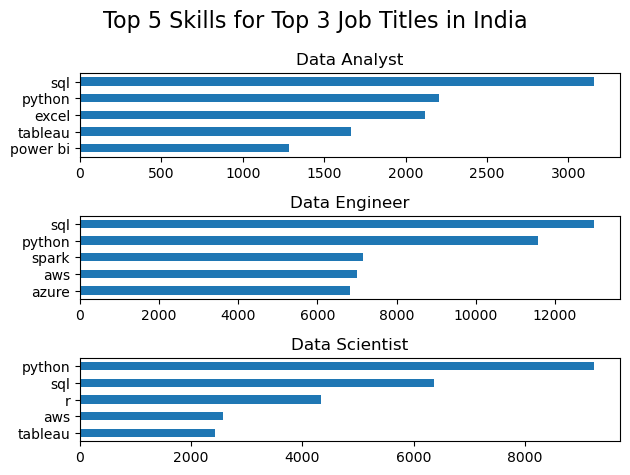

In [15]:
fig,ax=plt.subplots(len(job_titles),1)
for i,job_title in enumerate(job_titles):
    df_plot=df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
    df_plot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i],legend=False,title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    
fig.suptitle('Top 5 Skills for Top 3 Job Titles in India',fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
df_job_title_count=df_india['job_title_short'].value_counts().reset_index(name='job_total')


In [18]:
df_skills_count

,job_skills,job_title_short,skill_count
1374,sql,Data Engineer,12993
1088,python,Data Engineer,11568
1089,python,Data Scientist,9248
1327,spark,Data Engineer,7157
103,aws,Data Engineer,6993
...,...,...,...
34,angular.js,Data Scientist,1
49,arch,Business Analyst,1
787,mlpack,Data Engineer,1
1679,yarn,Senior Data Scientist,1


In [25]:
df_skills_perc=pd.merge(df_skills_count,df_job_title_count,how='left',on='job_title_short')
df_skills_perc['skill_percentage']=df_skills_perc['skill_count']/df_skills_perc['job_total']*100
df_skills_perc

,job_skills,job_title_short,skill_count,job_total,skill_percentage
0,sql,Data Engineer,12993,19062,68.161788
1,python,Data Engineer,11568,19062,60.686182
2,python,Data Scientist,9248,13279,69.643798
3,spark,Data Engineer,7157,19062,37.545903
4,aws,Data Engineer,6993,19062,36.685552
...,...,...,...,...,...
1684,angular.js,Data Scientist,1,13279,0.007531
1685,arch,Business Analyst,1,1887,0.052994
1686,mlpack,Data Engineer,1,19062,0.005246
1687,yarn,Senior Data Scientist,1,2486,0.040225


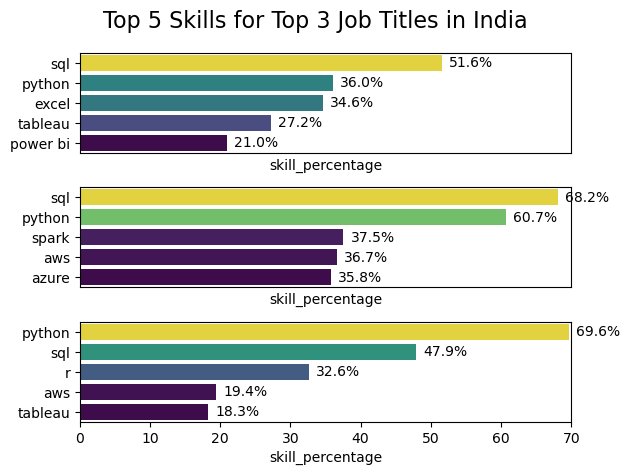

In [34]:
fig,ax=plt.subplots(len(job_titles),1)
for i,job_title in enumerate(job_titles):
    df_plot=df_skills_perc[df_skills_perc['job_title_short']==job_title].head(5)
    sns.barplot(data=df_plot,x='skill_percentage',y='job_skills',ax=ax[i],palette='viridis',hue='skill_count',legend=False)
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,70)

    for n,v in enumerate(df_plot['skill_percentage']):
        ax[i].text(v+1,n,f'{v:.1f}%',color='black',va='center')
    if i!=len(job_titles)-1:
        ax[i].set_xticks([])
fig.suptitle('Top 5 Skills for Top 3 Job Titles in India',fontsize=16)
plt.tight_layout()
plt.show()